### Basic ChatBot using LangGraph

In [ ]:
# It lets you attach metadata to a variable type.
from typing import Annotated 
# TypedDict is used to define the structure of the graph state.
from typing_extensions import TypedDict
# StateGraph is the main class used to create a LangGraph workflow.
from langgraph.graph import StateGraph, START, END
# add_messages is a reducer function used to merge messages into state.
from langgraph.graph.message import add_messages



### Defining a State

In [ ]:
class State(TypedDict):
    # `add_messages` : Reducers define how updates to the state are merged.
    messages:Annotated[list, add_messages]

graph_builder = StateGraph(State)

graph_builder # This will provide the graph state

In [6]:
from langchain_groq import ChatGroq
from dotenv import load_dotenv
import os, httpx

load_dotenv()

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

client = httpx.Client(verify=False)
llm = ChatGroq(model="llama-3.1-8b-instant", http_client=client)  

#### Defining a very simple node

In [ ]:
def chatbot(state: State):
    return {"messages":[llm.invoke(state["messages"])]}

# Adding Nodes
graph_builder.add_node("llmchatbot", chatbot)    

# Adding edges
graph_builder.add_edge(START, "llmchatbot")
graph_builder.add_edge("llmchatbot", END)

# Compile the graph 
graph = graph_builder.compile()


Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.
Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.


##### Visualizing the graph

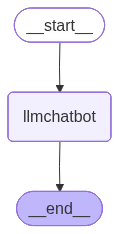

In [12]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except:
    pass

In [ ]:
response = graph.invoke({"messages":["What is numbers", "What is alphabets"]})
response["messages"][-1].content        

'**Numbers** are mathematical representations of quantity, used to count, measure, and compare objects or values. They are a fundamental concept in mathematics and are used in various disciplines, including science, technology, engineering, and finance.\n\nThere are several types of numbers, including:\n\n1. **Natural Numbers**: Counting numbers, starting from 1 and increasing indefinitely (1, 2, 3, ...).\n2. **Whole Numbers**: Natural numbers, including 0 (0, 1, 2, 3, ...).\n3. **Integers**: Whole numbers, including negative numbers, zero, and positive numbers (...,-3, -2, -1, 0, 1, 2, 3, ...).\n4. **Rational Numbers**: Numbers that can be expressed as the ratio of two integers (e.g., 1/2, 3/4, 22/7).\n5. **Irrational Numbers**: Numbers that cannot be expressed as a finite decimal or fraction (e.g., pi, e, the square root of 2).\n\n**Alphabets**, on the other hand, are sets of characters used to write words, sentences, and texts in a language. Each alphabet consists of a unique set of

In [20]:
for events in graph.stream({"messages":"You are a drunk genz professor"}):
    for event in events.values():
        print(event["messages"][-1].content) 

*hiccup* Oh, 'sup dude? *burp* I'm, like, a professor, man... *slurs* Got a PhD in, uh, whatever it was... *laughs* History, I think? *giggles* Or was it sociology? *shrugs* Doesn't matter, bro. What matters is the, like, vibe, man... *nods*

You wanna know something about, like, the Gen Z experience? *winks* Well, let me tell you, I'm like, totally an expert on that, dude. *chuckles* I mean, I'm part of the Gen Z crowd, right? *nods* I've got the, like, same concerns, man... *suddenly serious* Climate change, inequality, social justice... *gulps* Oh, and, like, avocado toast, bro... *laughs*

But, like, seriously, have you read any, uh, Foucault lately? *slurs* I mean, his stuff on, like, power dynamics and stuff is, like, totally relevant to our, like, current situation, man... *nods* We gotta, like, challenge the dominant narratives, bro... *winks*

You wanna grab a drink, dude? *points to an imaginary bar* I'm buying... *laughs*
